<h1 style="color: red; font-size: 48px; text-align: center;">Multi-Touch Attribution Intelligence</h1>

<center>
    <img src="https://media.giphy.com/media/qgQUggAC3Pfv687qPC/giphy.gif" alt="marketing analytics" height="200" width="500">
</center>

# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to fairly attribute conversion credit across every marketing touchpoint a customer sees on the way to a purchase, using <b>Shapley Values</b> from cooperative game theory, validating the result with an absorbing <b>Markov Chain</b> path model, and then <b>reallocating the advertising budget</b> toward the channels that are genuinely incremental.
    Working from GA4-style multi-channel customer journeys, we build exact, axiomatically-fair attribution and turn it into an actionable spend plan that lifts blended ROAS.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The default <b>last-click</b> attribution model that dominates the market is fundamentally incorrect &mdash; it hands 100% of the credit to the final touch and ignores roughly 85% of the customer journey, starving the awareness channels that actually <i>initiate</i> conversions.
    Commercial multi-touch attribution (MTA) tools that fix this cost $50&ndash;200K/year. The goal here is to recover the latent, incremental value of each channel directly from the journey data and act on it &mdash; on a fully free / offline stack.
</div>

# 🔭 Data Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
Each row of the dataset is one customer <b>journey</b> &mdash; an ordered sequence of marketing channels touched before the user converted (or did not).
<ol>
<li><p><strong><code>user_id</code></strong>: Unique identifier for the customer journey.</p></li>
<li><p><strong><code>path</code></strong>: The ordered channel sequence, e.g. <code>Display &gt; Paid Search &gt; Email</code>. This is the core signal every attribution model consumes.</p></li>
<li><p><strong><code>path_length</code></strong>: Number of touchpoints in the journey (journeys are right-skewed &mdash; most are short).</p></li>
<li><p><strong><code>n_unique_channels</code></strong>: Count of <i>distinct</i> channels in the journey &mdash; the size of the coalition for the Shapley game.</p></li>
<li><p><strong><code>converted</code></strong>: Binary target (1 = the journey ended in a purchase, 0 = no purchase).</p></li>
<li><p><strong><code>revenue</code></strong>: Order value on conversion (0 when the journey did not convert).</p></li>
<li><p><strong><code>first_touch</code></strong>: The channel that <i>initiated</i> the journey (top-of-funnel).</p></li>
<li><p><strong><code>last_touch</code></strong>: The channel that <i>closed</i> the journey &mdash; the only channel last-click attribution ever rewards.</p></li>
</ol>
<p>
The eight channels modelled are <code>Paid Search</code>, <code>Organic Search</code>, <code>Display</code>, <code>Paid Social</code>, <code>Email</code>, <code>Video</code>, <code>Referral</code> and <code>Direct</code>. Each carries a latent &ldquo;conversion strength&rdquo; so that genuinely incremental channels drive conversions while assist-only channels do not &mdash; exactly the structure the Shapley and Markov engines are expected to recover.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Perform exploratory data analysis (EDA) on the journey paths, conversions and revenue.</li>
        <li>Compute <b>exact Shapley value</b> attribution (cooperative game theory) for all eight channels.</li>
        <li>Validate the credit with a <b>Markov-chain removal-effect</b> model and blend both into a composite score.</li>
        <li>Contrast the result against last-click / first-click / linear baselines to expose last-click bias.</li>
        <li>Reallocate the marketing budget with a <b>SciPy constrained optimiser</b> and quantify the ROAS uplift.</li>
    </ul>
</div>

# Importing Libraries

In [1]:
import warnings
from itertools import combinations
from math import factorial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

RNG_SEED = 42
CHANNELS = [
    "Paid Search", "Organic Search", "Display", "Paid Social",
    "Email", "Video", "Referral", "Direct",
]

# Load Data

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 18px; line-height: 1.6em; border-radius: 1.3em;">
    To keep the notebook fully self-contained we generate realistic multi-channel journeys whose schema mirrors the GA4 &rarr; BigQuery export. Each channel has a latent <code>strength</code> (incremental conversion power) and an <code>intro</code> probability (likelihood of starting a journey), so the data carries the exact latent structure the attribution engines must recover.
</div>

In [2]:
# Latent per-channel priors: ``strength`` drives incremental conversions,
# ``intro`` is the relative likelihood of *starting* a journey on that channel.
_CHANNEL_PRIORS = {
    "Paid Search":    {"strength": 0.55, "intro": 0.20},
    "Organic Search": {"strength": 0.45, "intro": 0.18},
    "Display":        {"strength": 0.12, "intro": 0.16},
    "Paid Social":    {"strength": 0.30, "intro": 0.17},
    "Email":          {"strength": 0.50, "intro": 0.06},
    "Video":          {"strength": 0.18, "intro": 0.10},
    "Referral":       {"strength": 0.28, "intro": 0.05},
    "Direct":         {"strength": 0.20, "intro": 0.08},
}


def generate_journeys(channels, n_users=20000, max_touchpoints=8,
                      avg_order_value=85.0, attribution_window_days=30, seed=42):
    """Generate ``n_users`` synthetic customer journeys (GA4-style)."""
    rng = np.random.default_rng(seed)
    n_ch = len(channels)
    strength = np.array([_CHANNEL_PRIORS[c]["strength"] for c in channels])
    intro = np.array([_CHANNEL_PRIORS[c]["intro"] for c in channels])
    intro = intro / intro.sum()

    rows = []
    for uid in range(n_users):
        path_len = int(min(max_touchpoints, 1 + rng.poisson(1.6)))
        path_idx = [int(rng.choice(n_ch, p=intro))]
        for _ in range(path_len - 1):
            probs = np.full(n_ch, 1.0)
            probs[path_idx[-1]] *= 0.4   # discourage immediate repeats
            probs = probs / probs.sum()
            path_idx.append(int(rng.choice(n_ch, p=probs)))

        unique_idx = sorted(set(path_idx))
        # Conversion prob: saturating function of summed strength of distinct channels.
        coalition_strength = strength[unique_idx].sum()
        p_conv = float(np.tanh(0.55 * coalition_strength))
        converted = int(rng.random() < p_conv)
        revenue = float(max(5.0, rng.gamma(4.0, avg_order_value / 4.0))) if converted else 0.0

        path_channels = [channels[i] for i in path_idx]
        rows.append({
            "user_id": f"u{uid:06d}",
            "path": " > ".join(path_channels),
            "path_length": path_len,
            "n_unique_channels": len(unique_idx),
            "converted": converted,
            "revenue": round(revenue, 2),
            "first_touch": path_channels[0],
            "last_touch": path_channels[-1],
        })
    return pd.DataFrame(rows)


journeys = generate_journeys(CHANNELS, n_users=20000, seed=RNG_SEED)
print(f"Generated {len(journeys):,} journeys across {len(CHANNELS)} channels")

Generated 20,000 journeys across 8 channels


In [3]:
journeys.head()

,user_id,path,path_length,n_unique_channels,converted,revenue,first_touch,last_touch
0,u000000,Direct > Video > Referral > Paid Search > Paid...,5,5,1,114.04,Direct,Paid Social
1,u000001,Paid Social > Paid Search > Referral,3,3,0,0.00,Paid Social,Referral
2,u000002,Paid Search > Email > Paid Search > Organic Se...,5,4,0,0.00,Paid Search,Video
3,u000003,Display > Organic Search > Paid Search,3,3,1,48.95,Display,Paid Search
4,u000004,Video > Referral > Display > Display,4,3,0,0.00,Video,Display


In [4]:
def custom_describe(df, categorical=False):
    if not categorical:
        df = df.select_dtypes(include=np.number)

    des = df.describe().T.round(2)
    des["count"] = des["count"].astype("int")

    if not categorical:
        des["skewness"] = df.skew().round(2)
        des["kurtosis"] = df.kurtosis().round(2)

    return des

In [5]:
def df_summary(df, label="Journeys"):
    console = Console()
    console.rule(f"[bold blue]{label} DataFrame Description[/bold blue]")
    console.print(f"[bold]Shape:[/bold] {df.shape}\n")

    # Numeric summary
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        console.print("[bold blue]Numerical Columns:[/bold blue]")
        num_stats = custom_describe(df[numeric_cols], categorical=False)
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in num_stats.columns:
            table.add_column(col)
        for idx, row in num_stats.iterrows():
            table.add_row(idx, *[f"{val:.2f}" if isinstance(val, (float, np.float64)) else str(val) for val in row])
        console.print(table)
        console.print("\n")

    # Categorical summary
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    if len(cat_cols) > 0:
        console.print("[bold blue]Categorical Columns:[/bold blue]")
        cat_stats = df[cat_cols].describe().T
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in cat_stats.columns:
            table.add_column(col)
        for idx, row in cat_stats.iterrows():
            table.add_row(idx, *[str(val) for val in row])
        console.print(table)
        console.print("\n")


df_summary(journeys)

───────────────────────────────────────── Journeys DataFrame Description ──────────────────────────────────────────

Shape: (20000, 8)

Numerical Columns:

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Column            ┃ count    ┃ mean  ┃ std   ┃ min  ┃ 25%  ┃ 50%  ┃ 75%   ┃ max    ┃ skewness ┃ kurtosis ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ path_length       │ 20000.00 │ 2.61  │ 1.26  │ 1.00 │ 2.00 │ 2.00 │ 3.00  │ 8.00   │ 0.76     │ 0.47     │
│ n_unique_channels │ 20000.00 │ 2.36  │ 1.04  │ 1.00 │ 2.00 │ 2.00 │ 3.00  │ 8.00   │ 0.57     │ 0.01     │
│ converted         │ 20000.00 │ 0.39  │ 0.49  │ 0.00 │ 0.00 │ 0.00 │ 1.00  │ 1.00   │ 0.47     │ -1.78    │
│ revenue           │ 20000.00 │ 32.79 │ 49.18 │ 0.00 │ 0.00 │ 0.00 │ 63.30 │ 367.68 │ 1.46     │ 1.61     │
└───────────────────┴──────────┴───────┴───────┴──────┴──────┴──────┴───────┴────────┴──────────┴──────────┘

Categorical Columns:

┏━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━┓
┃ Column      ┃ count ┃ unique ┃ top         ┃ freq ┃
┡━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━┩
│ user_id     │ 20000 │ 20000  │ u000000     │ 1    │
│ path        │ 20000 │ 3981   │ Paid Search │ 806  │
│ first_touch │ 20000 │ 8      │ Paid Search │ 4019 │
│ last_touch  │ 20000 │ 8      │ Paid Search │ 2770 │
└─────────────┴───────┴────────┴─────────────┴──────┘

# 🔍 Exploratory Data Analysis (EDA)

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to understand the structure of the customer journeys before modelling. 
    By visualising path lengths, channel frequencies, conversion behaviour and revenue, we can see which channels tend to <i>start</i> journeys, which tend to <i>close</i> them, and how the journey structure relates to conversion &mdash; the patterns the attribution models will formalise.
</div>

## 📊 Key Objectives of EDA

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of journey length, distinct channels, conversion and revenue.</li>
        <li>Understand which channels most often appear as <code>first_touch</code> vs <code>last_touch</code>.</li>
        <li>Compare conversion rates and average revenue across channels.</li>
        <li>Quantify the gap between where last-click looks (the closer) and where journeys actually begin.</li>
        <li>Identify correlations between journey-structure features and conversion.</li>
    </ul>
</div>

## 📈 Exploratory Steps

<div style="font-family: verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong>Data Quality Checks:</strong> Verify there are no missing values or duplicate journeys before modelling.</p></li>
<li><p><strong>Univariate Analysis:</strong> Distributions of <code>path_length</code>, <code>n_unique_channels</code>, <code>revenue</code> and the <code>converted</code> label.</p></li>
<li><p><strong>Channel Frequency:</strong> How often each channel appears as the first vs last touch of a journey.</p></li>
<li><p><strong>Conversion / Target Analysis:</strong> Overall conversion rate and the revenue distribution among converters.</p></li>
<li><p><strong>Bivariate Analysis:</strong> Conversion rate by channel presence and correlation between structural features and conversion.</p></li>
</ol>
</div>

In [6]:
target = "converted"
numerical_features = ["path_length", "n_unique_channels", "revenue"]
categorical_features = ["first_touch", "last_touch"]

# Long-format touch table: one row per (journey, channel-touched) for frequency stats.
touch_rows = []
for path, conv in zip(journeys["path"], journeys["converted"]):
    for ch in dict.fromkeys(path.split(" > ")):   # distinct, order-preserving
        touch_rows.append({"channel": ch, "converted": conv})
touches = pd.DataFrame(touch_rows)

## Null Value Check

In [7]:
pd.DataFrame({
    "Columns": journeys.columns.to_list(),
    "# Null": journeys.isna().sum().values,
})

,Columns,# Null
0,user_id,0
1,path,0
2,path_length,0
3,n_unique_channels,0
4,converted,0
5,revenue,0
6,first_touch,0
7,last_touch,0


## Duplicate Check

In [8]:
num_duplicates = journeys.drop(columns="user_id").duplicated().sum()
print(f"Number of duplicate journeys (ignoring user_id): {num_duplicates}")

Number of duplicate journeys (ignoring user_id): 10142


## Univariate Analysis

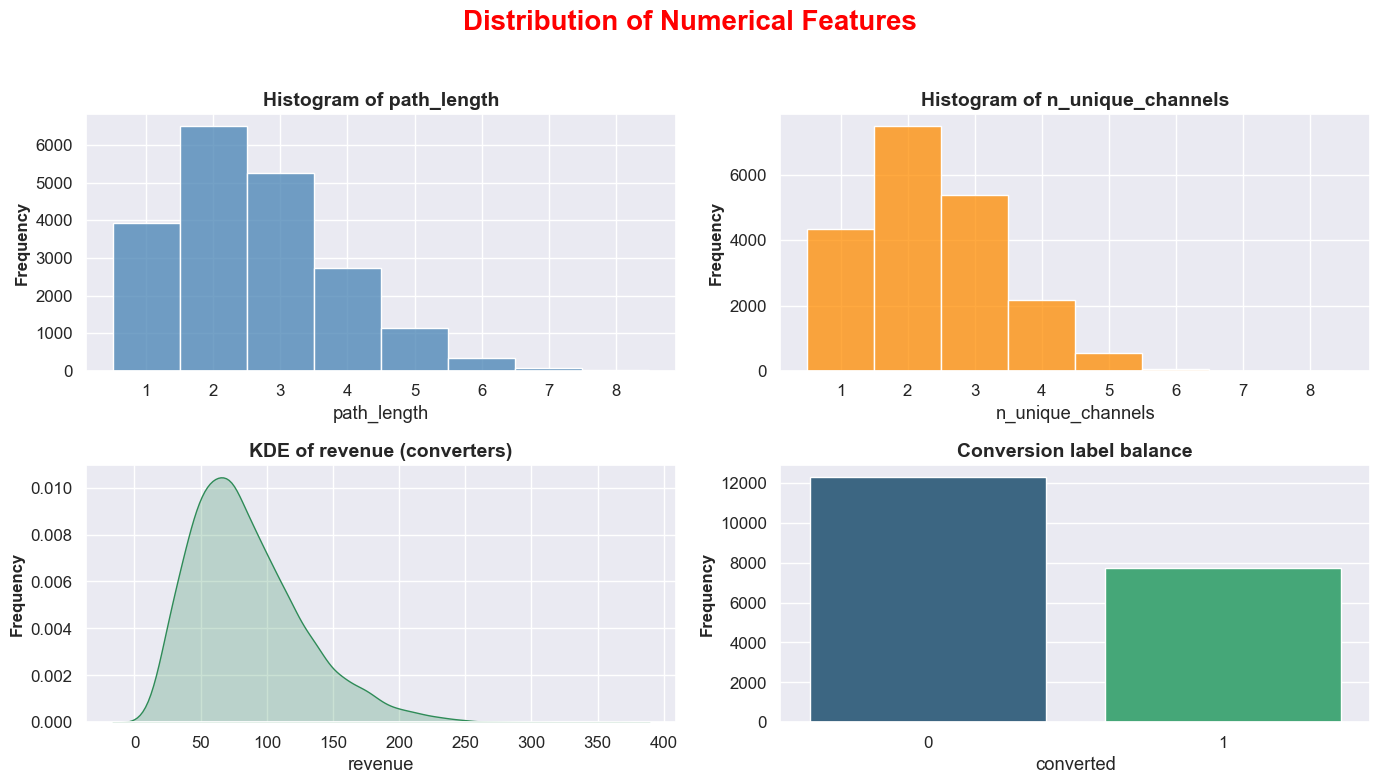

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

sns.histplot(data=journeys, x="path_length", ax=axes[0], discrete=True, color="steelblue")
axes[0].set_title("Histogram of path_length", fontweight="bold", fontsize=14)

sns.histplot(data=journeys, x="n_unique_channels", ax=axes[1], discrete=True, color="darkorange")
axes[1].set_title("Histogram of n_unique_channels", fontweight="bold", fontsize=14)

sns.kdeplot(data=journeys[journeys["revenue"] > 0], x="revenue", ax=axes[2], fill=True, color="seagreen")
axes[2].set_title("KDE of revenue (converters)", fontweight="bold", fontsize=14)

sns.countplot(data=journeys, x="converted", ax=axes[3], palette="viridis")
axes[3].set_title("Conversion label balance", fontweight="bold", fontsize=14)

for ax in axes:
    ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Numerical Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

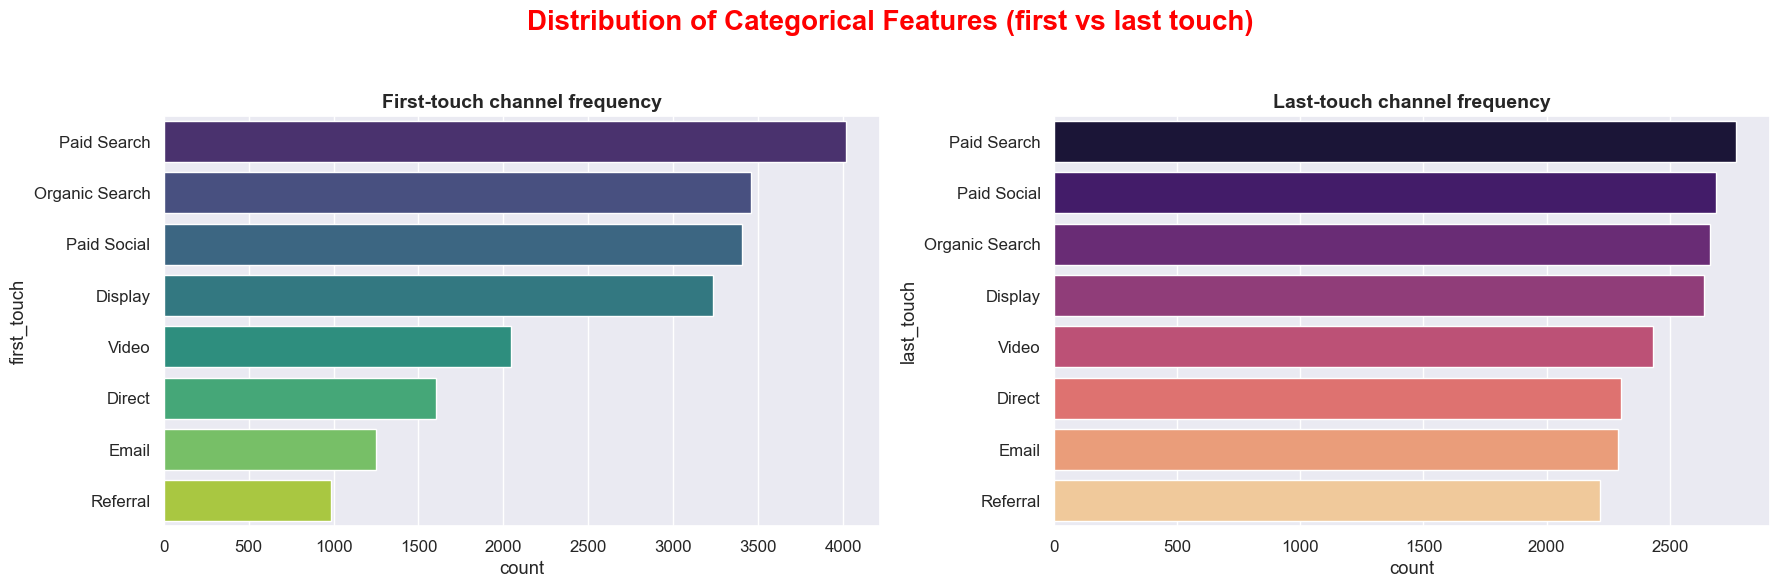

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

first_order = journeys["first_touch"].value_counts().index
sns.countplot(data=journeys, y="first_touch", ax=axes[0], order=first_order, palette="viridis")
axes[0].set_title("First-touch channel frequency", fontweight="bold", fontsize=14)

last_order = journeys["last_touch"].value_counts().index
sns.countplot(data=journeys, y="last_touch", ax=axes[1], order=last_order, palette="magma")
axes[1].set_title("Last-touch channel frequency", fontweight="bold", fontsize=14)

plt.suptitle("Distribution of Categorical Features (first vs last touch)", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Target Analysis

Overall conversion rate : 38.59%
Converting journeys      : 7,719
Total attributed revenue : 655,738


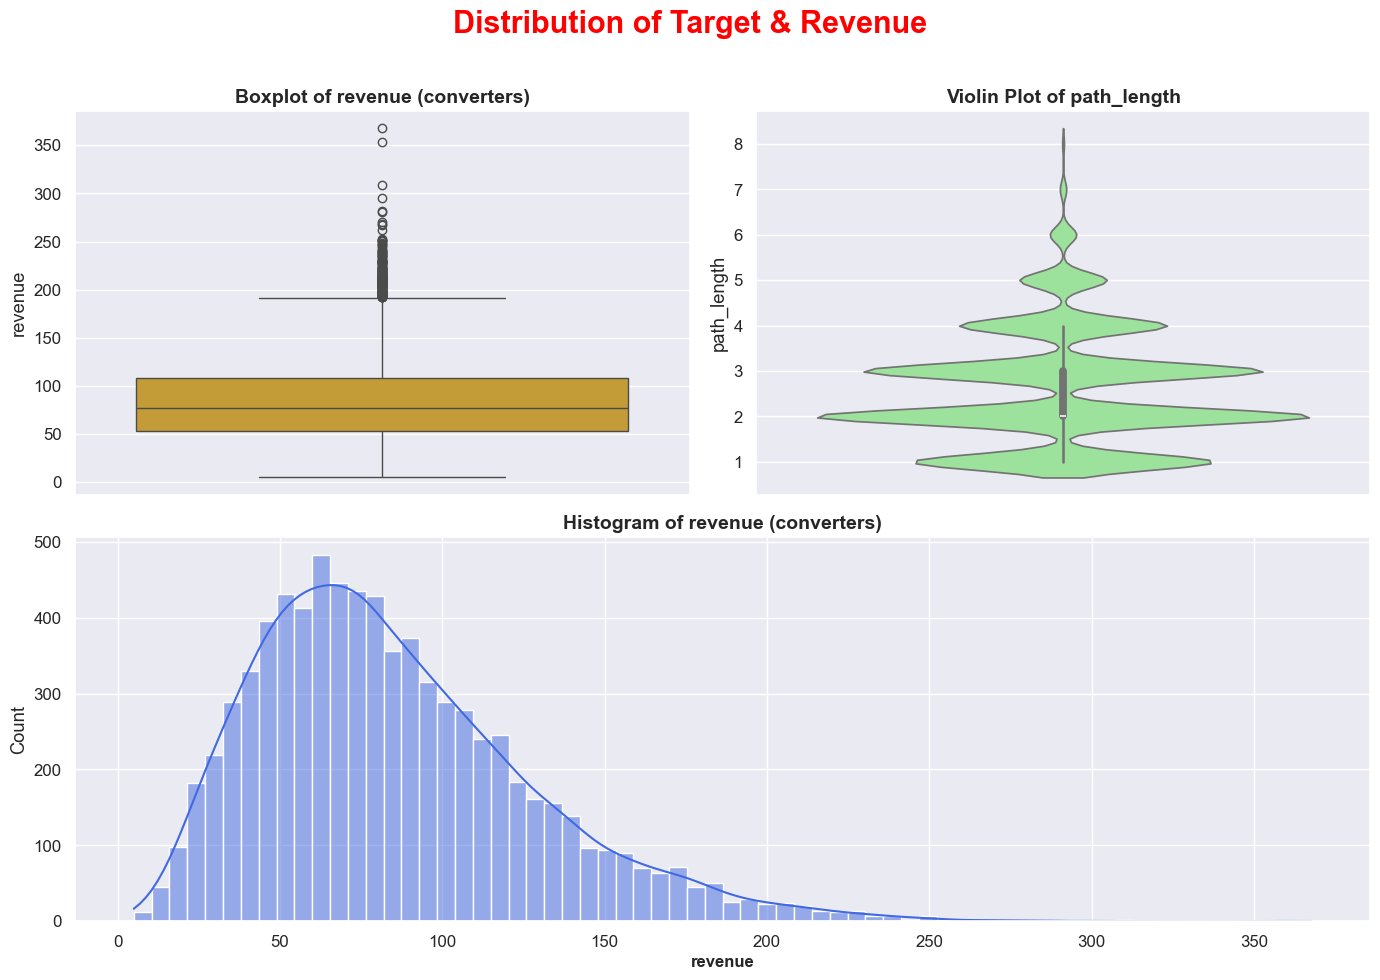

In [11]:
conv_rate = journeys["converted"].mean()
total_rev = journeys.loc[journeys["converted"] == 1, "revenue"].sum()
print(f"Overall conversion rate : {conv_rate:.2%}")
print(f"Converting journeys      : {int(journeys['converted'].sum()):,}")
print(f"Total attributed revenue : {total_rev:,.0f}")

fig, axes = plt.subplot_mosaic([["A", "B"], ["C", "C"]], figsize=(14, 10))
conv = journeys[journeys["converted"] == 1]

sns.boxplot(y="revenue", data=conv, ax=axes["A"], color="goldenrod")
axes["A"].set_title("Boxplot of revenue (converters)", fontweight="bold", fontsize=14)

sns.violinplot(y="path_length", data=journeys, ax=axes["B"], color="lightgreen")
axes["B"].set_title("Violin Plot of path_length", fontweight="bold", fontsize=14)

sns.histplot(conv["revenue"], kde=True, ax=axes["C"], color="royalblue")
axes["C"].set_title("Histogram of revenue (converters)", fontweight="bold", fontsize=14)
axes["C"].set_xlabel("revenue", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Target & Revenue", fontsize=22, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Bivariate Analysis

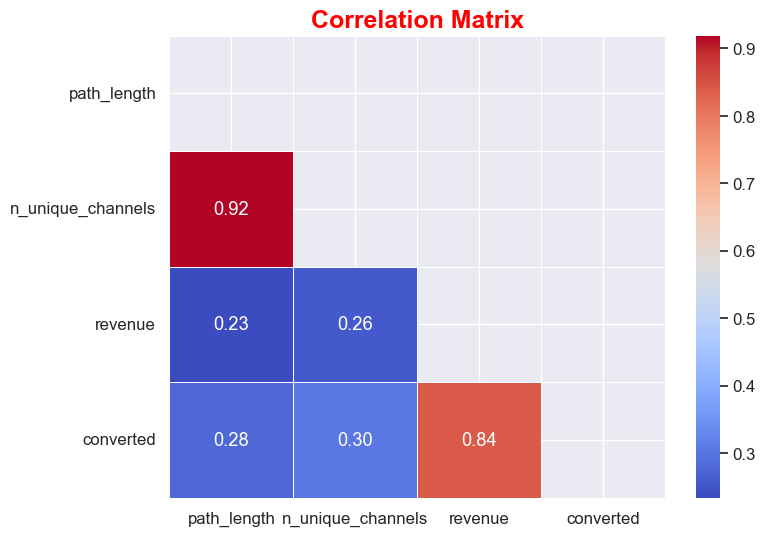

In [12]:
corr = journeys[numerical_features + ["converted"]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=18, fontweight="bold", color="red")
plt.show()

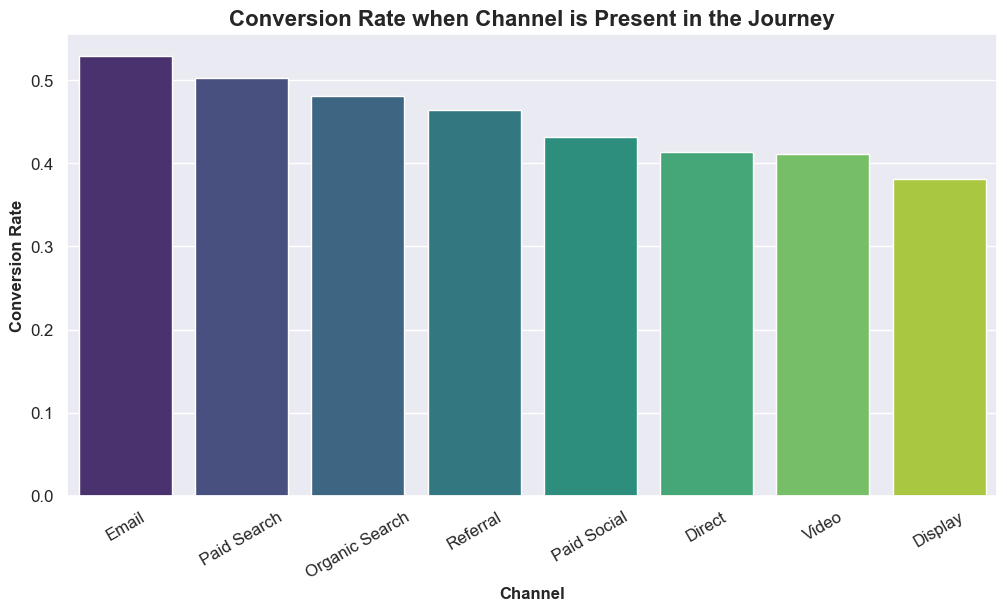

In [13]:
# Conversion rate when a channel is present anywhere in the journey.
present_conv = touches.groupby("channel")["converted"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=present_conv.index, y=present_conv.values, palette="viridis")
plt.title("Conversion Rate when Channel is Present in the Journey", fontsize=16, fontweight="bold")
plt.xlabel("Channel", fontsize=12, fontweight="bold")
plt.ylabel("Conversion Rate", fontsize=12, fontweight="bold")
plt.xticks(rotation=30)
plt.show()

# 🛠️ Feature Engineering & Attribution Engines

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Instead of one-hot encoding for a regressor, the &ldquo;features&rdquo; here are the <b>attribution engines</b> themselves &mdash; functions that turn the raw journey paths into a fair per-channel credit share. We implement three: an <b>exact Shapley value</b> engine, a <b>Markov-chain removal-effect</b> engine, and a set of heuristic <b>baselines</b> (last/first/linear) to compare against.
</div>

## 🔧 The Characteristic Function

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Channels are <b>players in a cooperative game</b>. The worth <code>v(S)</code> of a coalition <code>S</code> is the empirical conversion rate of journeys whose touched channel-set is a subset of <code>S</code> &mdash; the data-driven characteristic function of Shao &amp; Li (2011), the same formulation GA4 uses. Because journeys are capped at 8 distinct channels (<code>2&#8312; = 256</code> coalitions), the Shapley value is computed <b>exactly</b>, not Monte-Carlo approximated.
</div>

In [14]:
# ---- Exact Shapley value attribution -------------------------------------
def _conversion_rate_by_subset(journeys, channels):
    """Map each observed channel-set -> conversion rate of those journeys."""
    idx = {c: i for i, c in enumerate(channels)}
    sets = {}
    for path, conv in zip(journeys["path"], journeys["converted"]):
        cset = frozenset(idx[c] for c in path.split(" > ") if c in idx)
        if not cset:
            continue
        sets.setdefault(cset, []).append(int(conv))
    return {k: float(np.mean(v)) for k, v in sets.items()}


def _characteristic_function(subset_rates):
    """v(S): mean conversion rate among journeys whose channel-set is a subset of S."""
    cache = {}
    def v(coalition):
        if coalition in cache:
            return cache[coalition]
        total, count = 0.0, 0
        for cset, rate in subset_rates.items():
            if cset <= coalition:
                total += rate
                count += 1
        worth = total / count if count else 0.0
        cache[coalition] = worth
        return worth
    return v


def shapley_attribution(journeys, channels):
    """Exact Shapley credit per channel (average marginal contribution)."""
    n = len(channels)
    v = _characteristic_function(_conversion_rate_by_subset(journeys, channels))
    players = list(range(n))
    phi = np.zeros(n)
    weights = {s: factorial(s) * factorial(n - s - 1) / factorial(n) for s in range(n)}

    for i in players:
        others = [p for p in players if p != i]
        for size in range(len(others) + 1):
            w = weights[size]
            for combo in combinations(others, size):
                S = frozenset(combo)
                phi[i] += w * (v(S | {i}) - v(S))

    phi = np.clip(phi, 0.0, None)
    total = phi.sum()
    share = phi / total if total > 0 else np.full(n, 1.0 / n)

    total_conv = int(journeys["converted"].sum())
    total_rev = float(journeys.loc[journeys["converted"] == 1, "revenue"].sum())
    out = pd.DataFrame({
        "shapley_value": phi,
        "credit_share": share,
        "attributed_conversions": share * total_conv,
        "attributed_revenue": share * total_rev,
    }, index=channels)
    out.index.name = "channel"
    return out.sort_values("credit_share", ascending=False)

In [15]:
# ---- Markov-chain removal-effect attribution -----------------------------
START, CONV, NULL = "(start)", "(conversion)", "(null)"


def build_transition_matrix(journeys, channels):
    states = [START] + list(channels) + [CONV, NULL]
    sidx = {s: i for i, s in enumerate(states)}
    counts = np.zeros((len(states), len(states)))
    for path, conv in zip(journeys["path"], journeys["converted"]):
        seq = [START] + [c for c in path.split(" > ") if c in sidx]
        seq.append(CONV if conv else NULL)
        for a, b in zip(seq[:-1], seq[1:]):
            counts[sidx[a], sidx[b]] += 1
    counts[sidx[CONV], sidx[CONV]] = 1.0
    counts[sidx[NULL], sidx[NULL]] = 1.0
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return counts / row_sums, states


def _conversion_probability(trans, states):
    sidx = {s: i for i, s in enumerate(states)}
    absorbing = [sidx[CONV], sidx[NULL]]
    transient = [i for i in range(len(states)) if i not in absorbing]
    Q = trans[np.ix_(transient, transient)]
    R = trans[np.ix_(transient, absorbing)]
    fundamental = np.linalg.inv(np.eye(len(transient)) - Q)
    B = fundamental @ R
    return float(B[transient.index(sidx[START]), absorbing.index(sidx[CONV])])


def markov_attribution(journeys, channels):
    trans, states = build_transition_matrix(journeys, channels)
    sidx = {s: i for i, s in enumerate(states)}
    base_p = _conversion_probability(trans, states)

    removal = {}
    for ch in channels:
        ci = sidx[ch]
        t2 = trans.copy()
        incoming = t2[:, ci].copy()
        t2[:, ci] = 0.0
        t2[:, sidx[NULL]] += incoming
        t2[ci, :] = 0.0
        t2[ci, sidx[NULL]] = 1.0
        rs = t2.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1.0
        t2 = t2 / rs
        p_without = _conversion_probability(t2, states)
        removal[ch] = max(0.0, (base_p - p_without) / base_p) if base_p > 0 else 0.0

    re = pd.Series(removal)
    share = re / re.sum() if re.sum() > 0 else pd.Series(np.full(len(channels), 1/len(channels)), index=channels)
    out = pd.DataFrame({"removal_effect": re, "credit_share": share})
    out.index.name = "channel"
    return out.sort_values("credit_share", ascending=False), trans, states

In [16]:
# ---- Heuristic baselines & composite blend -------------------------------
def _to_share(credit, channels):
    total = sum(credit.values())
    if total <= 0:
        return pd.Series({c: 1.0 / len(channels) for c in channels})
    return pd.Series({c: credit[c] / total for c in channels})


def baseline_attributions(journeys, channels):
    conv = journeys[journeys["converted"] == 1]
    lc = {c: 0.0 for c in channels}
    fc = {c: 0.0 for c in channels}
    li = {c: 0.0 for c in channels}
    for path in conv["path"]:
        steps = path.split(" > ")
        lc[steps[-1]] += 1.0
        fc[steps[0]] += 1.0
        touched = list(dict.fromkeys(steps))
        for c in touched:
            li[c] += 1.0 / len(touched)
    out = pd.DataFrame({
        "last_click": _to_share(lc, channels),
        "first_click": _to_share(fc, channels),
        "linear": _to_share(li, channels),
    })
    out.index.name = "channel"
    return out


def composite_attribution(shap, mark, w_shapley=0.70, w_markov=0.30):
    df = pd.DataFrame(index=shap.index)
    df.index.name = "channel"
    df["shapley_share"] = shap["credit_share"]
    df["markov_share"] = mark["credit_share"]
    df["composite_share"] = w_shapley * df["shapley_share"] + w_markov * df["markov_share"]
    df["composite_share"] = df["composite_share"] / df["composite_share"].sum()
    return df.sort_values("composite_share", ascending=False)

# 🏗️ Model Building

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    We now run all three attribution engines on the journey data, blend Shapley and Markov into a robust <b>composite score</b>, and contrast everything against the heuristic baselines that dominate the market &mdash; exposing exactly how much credit last-click steals from the upper funnel.
</div>

## 🔭 The Models

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>Shapley Value (exact):</strong> Fair credit satisfying the efficiency, symmetry, null-player and additivity axioms.</li>
        <li><strong>Markov Chain (removal effect):</strong> Structural necessity &mdash; how much conversion probability collapses when a channel is removed.</li>
        <li><strong>Composite:</strong> <code>0.70 &times; Shapley + 0.30 &times; Markov</code> &mdash; what the budget optimiser consumes.</li>
        <li><strong>Baselines:</strong> last-click / first-click / linear for an apples-to-apples comparison.</li>
    </ul>
</div>

In [17]:
shap_df = shapley_attribution(journeys, CHANNELS)
shap_df.round(4)

,shapley_value,credit_share,attributed_conversions,attributed_revenue
channel,,,,
Paid Search,0.1304,0.2254,1739.8753,147804.5199
Email,0.1223,0.2114,1632.0960,138648.5419
Organic Search,0.1065,0.1842,1421.9144,120793.3603
Referral,0.0783,0.1353,1044.5621,88736.8169
Paid Social,0.0657,0.1136,877.0425,74505.8263
Direct,0.0306,0.0529,407.9552,34656.2866
Video,0.0301,0.0520,401.2301,34084.9843
Display,0.0146,0.0252,194.3245,16508.1037


In [18]:
mark_df, trans, states = markov_attribution(journeys, CHANNELS)
mark_df.round(4)

,removal_effect,credit_share
channel,,
Paid Search,0.3556,0.1573
Organic Search,0.3311,0.1464
Paid Social,0.3101,0.1371
Display,0.2821,0.1248
Email,0.2603,0.1151
Video,0.2531,0.1119
Direct,0.2375,0.1051
Referral,0.2315,0.1024


In [19]:
comp_df = composite_attribution(shap_df, mark_df)
comp_df.round(4)

,shapley_share,markov_share,composite_share
channel,,,
Paid Search,0.2254,0.1573,0.2050
Email,0.2114,0.1151,0.1825
Organic Search,0.1842,0.1464,0.1729
Referral,0.1353,0.1024,0.1254
Paid Social,0.1136,0.1371,0.1207
Video,0.0520,0.1119,0.0700
Direct,0.0529,0.1051,0.0685
Display,0.0252,0.1248,0.0551


## Markov Transition Heatmap

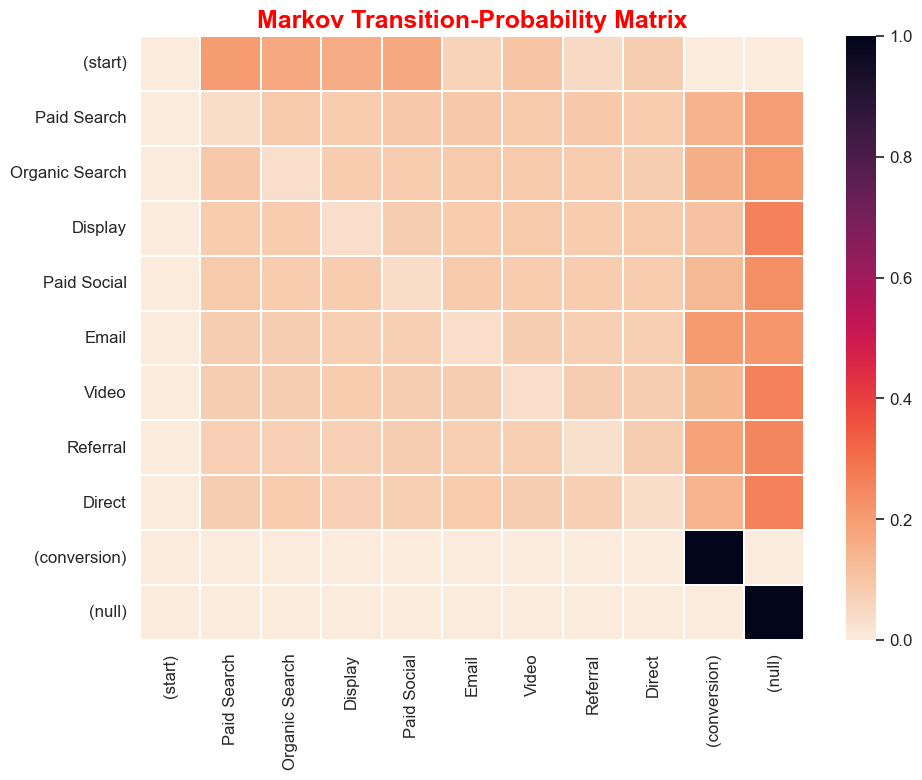

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(trans, index=states, columns=states), annot=False,
            cmap="rocket_r", linewidths=0.3)
plt.title("Markov Transition-Probability Matrix", fontsize=18, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

## Model Comparison

In [21]:
baselines = baseline_attributions(journeys, CHANNELS)

comparison = pd.DataFrame({
    "shapley": shap_df["credit_share"],
    "markov": mark_df["credit_share"],
    "composite": comp_df["composite_share"],
}).join(baselines)
comparison = comparison.loc[comp_df.index]   # order by composite share
comparison.round(4)

,shapley,markov,composite,last_click,first_click,linear
channel,,,,,,
Paid Search,0.2254,0.1573,0.2050,0.1526,0.2415,0.1845
Email,0.2114,0.1151,0.1825,0.1430,0.0718,0.1204
Organic Search,0.1842,0.1464,0.1729,0.1469,0.1942,0.1596
Referral,0.1353,0.1024,0.1254,0.1223,0.0461,0.0962
Paid Social,0.1136,0.1371,0.1207,0.1251,0.1645,0.1358
Video,0.0520,0.1119,0.0700,0.1061,0.0858,0.1005
Direct,0.0529,0.1051,0.0685,0.1053,0.0678,0.0935
Display,0.0252,0.1248,0.0551,0.0986,0.1284,0.1095


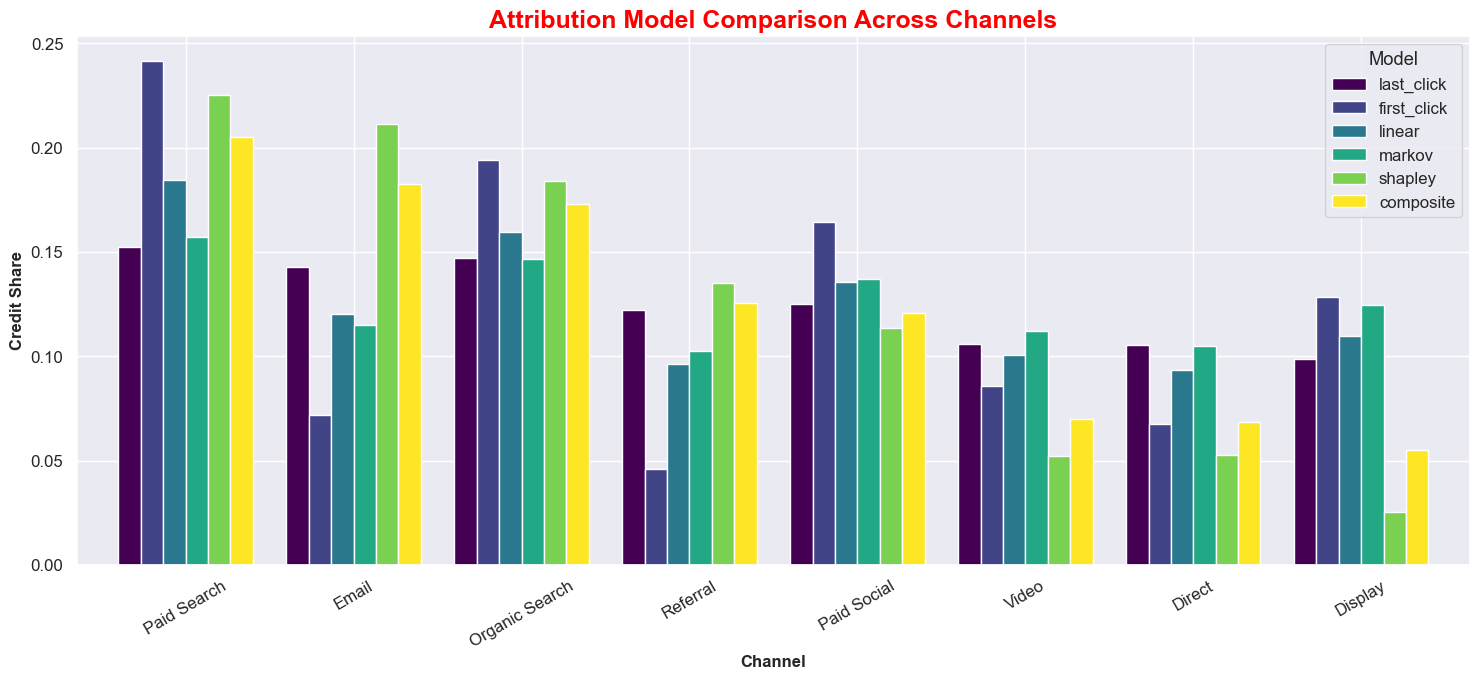

In [22]:
ax = comparison[["last_click", "first_click", "linear", "markov", "shapley", "composite"]].plot(
    kind="bar", figsize=(15, 7), width=0.8, colormap="viridis")
ax.set_title("Attribution Model Comparison Across Channels", fontsize=18, fontweight="bold", color="red")
ax.set_xlabel("Channel", fontsize=12, fontweight="bold")
ax.set_ylabel("Credit Share", fontsize=12, fontweight="bold")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Shapley vs Last-Click (the headline result)

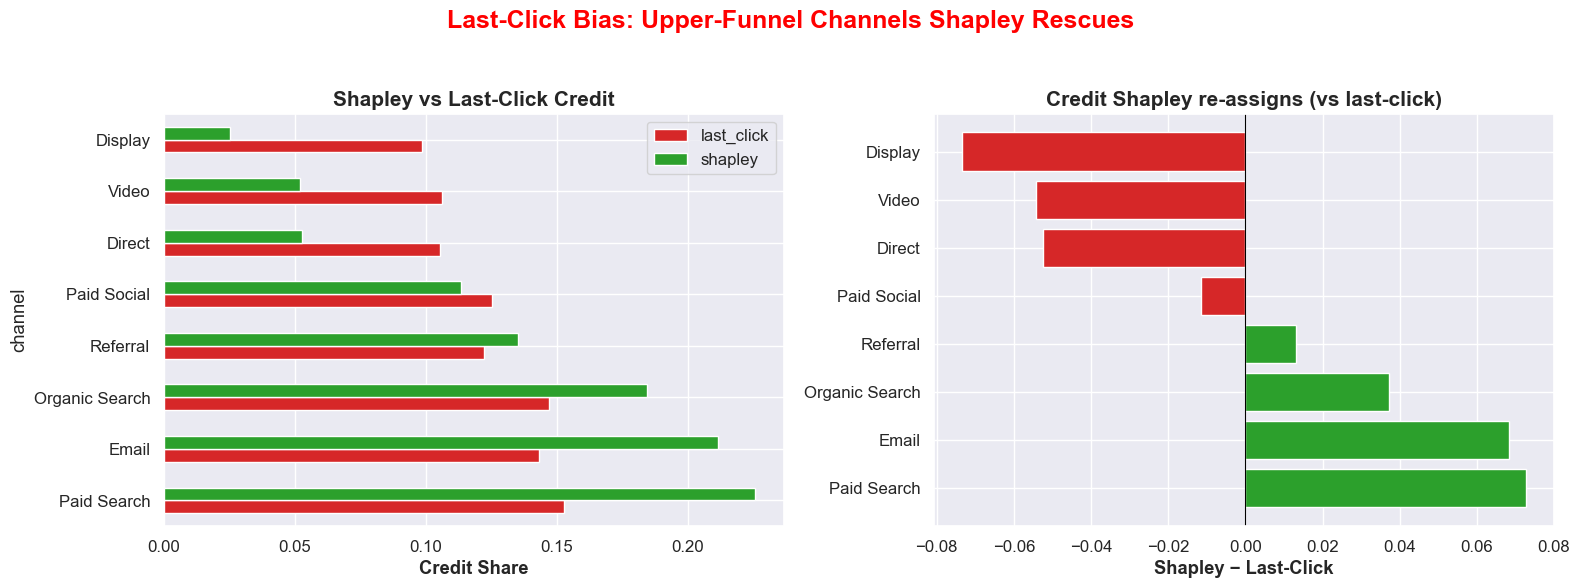

In [23]:
compare = pd.DataFrame({
    "last_click": baselines["last_click"],
    "shapley": shap_df["credit_share"],
}).loc[shap_df.index]
compare["delta"] = compare["shapley"] - compare["last_click"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
compare[["last_click", "shapley"]].plot(kind="barh", ax=axes[0], color=["#d62728", "#2ca02c"])
axes[0].set_title("Shapley vs Last-Click Credit", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Credit Share", fontweight="bold")

colors = ["#2ca02c" if d >= 0 else "#d62728" for d in compare["delta"]]
axes[1].barh(compare.index, compare["delta"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Credit Shapley re-assigns (vs last-click)", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Shapley − Last-Click", fontweight="bold")

plt.suptitle("Last-Click Bias: Upper-Funnel Channels Shapley Rescues",
             fontsize=18, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 💰 Budget Optimization

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 18px; line-height: 1.6em; border-radius: 1.3em;">
    Each channel's revenue response to spend is a concave power curve <code>revenue_i(s) = k_i &middot; s^&gamma;</code> calibrated from its composite attribution share. We then <b>maximise total revenue subject to a fixed budget and per-channel min/max share</b> using SciPy SLSQP &mdash; turning fair attribution into an actionable spend plan.
</div>

In [24]:
def optimize_budget(attribution, total_budget, current_spend=None,
                    min_share=0.02, max_share=0.40, gamma=0.65, baseline_roas=2.8):
    channels = list(attribution.index)
    n = len(channels)
    shares = attribution["composite_share"].to_numpy(dtype=float)

    if current_spend is None:
        current = np.full(n, total_budget / n)   # naive even split baseline
    else:
        current = np.array([current_spend.get(c, total_budget / n) for c in channels])
        current = current / current.sum() * total_budget

    target_revenue = baseline_roas * total_budget
    attributed = shares / shares.sum() * target_revenue
    safe_spend = np.where(current <= 0, 1.0, current)
    k = attributed / np.power(safe_spend, gamma)

    def total_revenue(spend):
        return float(np.sum(k * np.power(np.clip(spend, 0, None), gamma)))

    constraints = [{"type": "eq", "fun": lambda s: np.sum(s) - total_budget}]
    bounds = [(min_share * total_budget, max_share * total_budget)] * n
    result = minimize(lambda s: -total_revenue(s), x0=current, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"maxiter": 500, "ftol": 1e-9})

    optimized = np.clip(result.x, 0, None)
    optimized = optimized / optimized.sum() * total_budget

    alloc = pd.DataFrame({
        "composite_share": shares,
        "current_spend": current,
        "optimized_spend": optimized,
        "delta_spend": optimized - current,
        "delta_pct": np.where(current > 0, (optimized - current) / current, 0.0),
    }, index=channels)
    alloc.index.name = "channel"
    return alloc.sort_values("optimized_spend", ascending=False), total_revenue(current), total_revenue(optimized)


TOTAL_BUDGET = 2_000_000.0
alloc, cur_rev, opt_rev = optimize_budget(comp_df, TOTAL_BUDGET)
print(f"Current  predicted revenue : {cur_rev:,.0f}  (ROAS {cur_rev/TOTAL_BUDGET:.2f})")
print(f"Optimised predicted revenue: {opt_rev:,.0f}  (ROAS {opt_rev/TOTAL_BUDGET:.2f})")
print(f"Revenue uplift             : {opt_rev-cur_rev:,.0f}  (+{(opt_rev-cur_rev)/cur_rev:.1%})")
alloc.round(2)

Current  predicted revenue : 5,600,000  (ROAS 2.80)
Optimised predicted revenue: 6,436,227  (ROAS 3.22)
Revenue uplift             : 836,227  (+14.9%)


,composite_share,current_spend,optimized_spend,delta_spend,delta_pct
channel,,,,,
Paid Search,0.20,250000.0,653371.58,403371.58,1.61
Email,0.18,250000.0,487388.39,237388.39,0.95
Organic Search,0.17,250000.0,423731.86,173731.86,0.69
Referral,0.13,250000.0,163940.53,-86059.47,-0.34
Paid Social,0.12,250000.0,151567.64,-98432.36,-0.39
Video,0.07,250000.0,40000.00,-210000.00,-0.84
Direct,0.07,250000.0,40000.00,-210000.00,-0.84
Display,0.06,250000.0,40000.00,-210000.00,-0.84


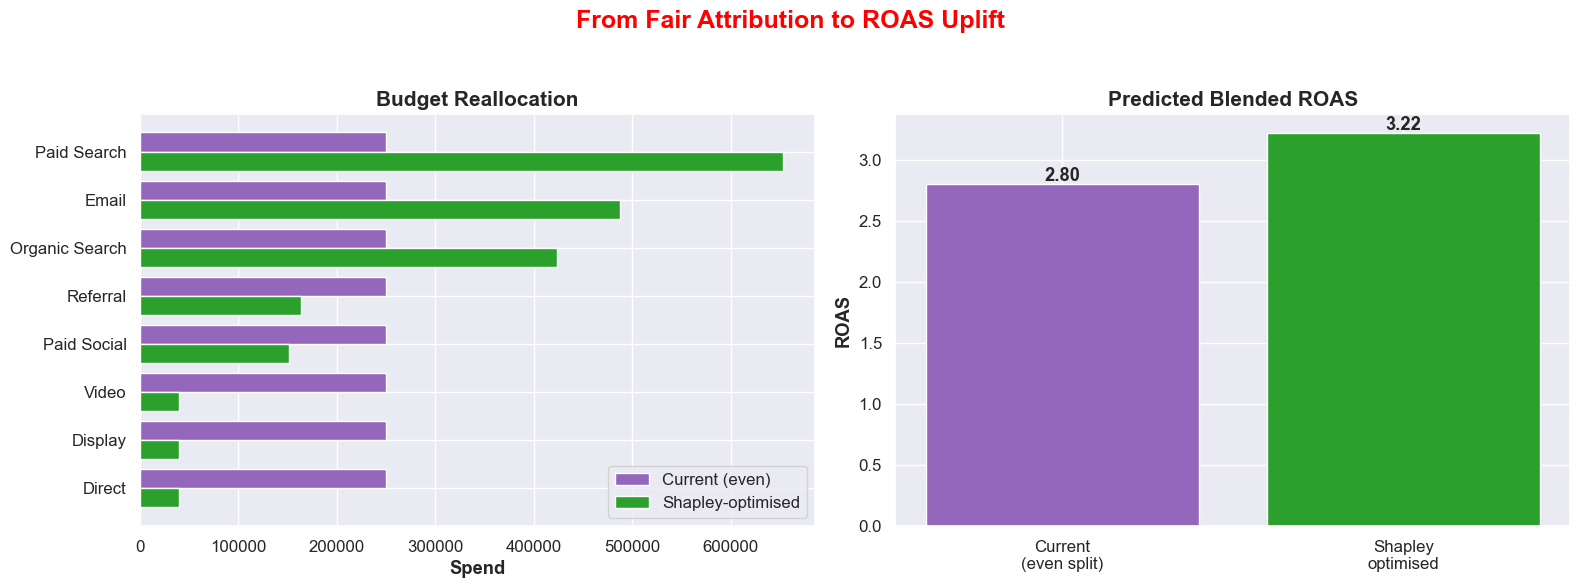

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

a = alloc.sort_values("optimized_spend")
idx = np.arange(len(a))
h = 0.4
axes[0].barh(idx + h/2, a["current_spend"], height=h, label="Current (even)", color="#9467bd")
axes[0].barh(idx - h/2, a["optimized_spend"], height=h, label="Shapley-optimised", color="#2ca02c")
axes[0].set_yticks(idx)
axes[0].set_yticklabels(a.index)
axes[0].set_title("Budget Reallocation", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Spend", fontweight="bold")
axes[0].legend()

axes[1].bar(["Current\n(even split)", "Shapley\noptimised"], [cur_rev/TOTAL_BUDGET, opt_rev/TOTAL_BUDGET],
            color=["#9467bd", "#2ca02c"])
axes[1].set_title("Predicted Blended ROAS", fontsize=15, fontweight="bold")
axes[1].set_ylabel("ROAS", fontweight="bold")
for i, val in enumerate([cur_rev/TOTAL_BUDGET, opt_rev/TOTAL_BUDGET]):
    axes[1].text(i, val, f"{val:.2f}", ha="center", va="bottom", fontweight="bold")

plt.suptitle("From Fair Attribution to ROAS Uplift", fontsize=18, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📤 Results & Export

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 18px; line-height: 1.6em; border-radius: 1.3em;">
    The final deliverable is a per-channel table joining the composite attribution credit to the recommended spend reallocation &mdash; the action plan a marketing team (or the autonomous Attribution Advisor agent) would execute.
</div>

In [26]:
final = comp_df.join(alloc[["current_spend", "optimized_spend", "delta_spend", "delta_pct"]])
final = final.sort_values("composite_share", ascending=False)
final.to_csv("attribution_budget_plan.csv")
print("Saved -> attribution_budget_plan.csv")
final.round(4)

Saved -> attribution_budget_plan.csv


,shapley_share,markov_share,composite_share,current_spend,optimized_spend,delta_spend,delta_pct
channel,,,,,,,
Paid Search,0.2254,0.1573,0.2050,250000.0,653371.5803,403371.5803,1.6135
Email,0.2114,0.1151,0.1825,250000.0,487388.3897,237388.3897,0.9496
Organic Search,0.1842,0.1464,0.1729,250000.0,423731.8552,173731.8552,0.6949
Referral,0.1353,0.1024,0.1254,250000.0,163940.5325,-86059.4675,-0.3442
Paid Social,0.1136,0.1371,0.1207,250000.0,151567.6421,-98432.3579,-0.3937
Video,0.0520,0.1119,0.0700,250000.0,40000.0000,-210000.0000,-0.8400
Direct,0.0529,0.1051,0.0685,250000.0,40000.0000,-210000.0000,-0.8400
Display,0.0252,0.1248,0.0551,250000.0,40000.0000,-210000.0000,-0.8400


In [27]:
# Quick verification of the Shapley efficiency axiom: shares sum to 1.
print(f"Shapley shares sum to   : {shap_df['credit_share'].sum():.6f}")
print(f"Composite shares sum to : {comp_df['composite_share'].sum():.6f}")
print(f"Budget fully allocated  : {alloc['optimized_spend'].sum():,.0f} / {TOTAL_BUDGET:,.0f}")

Shapley shares sum to   : 1.000000
Composite shares sum to : 1.000000
Budget fully allocated  : 2,000,000 / 2,000,000


<h2 style="color: red; text-align: center;">Thank you for reading, happy optimising! 🚀</h2>

<center>
    <img src="https://media.giphy.com/media/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="100" width="200">
</center>